### ZNet Sample Notebook

In [1]:
import os
import pandas as pd

from DGP.generate_datasets import generate_datasets
from utils.train_models import train_znet
from utils.evaluate_models import evaluate_generatediv_dataset

#### ZNet IV generation

In [4]:
# Generating all semi-synthetic IHDP datasets
datasets = generate_datasets(data_file='DGP/datafiles/ihdp.RData')
datasets.keys()

dict_keys(['linear_disjoint', 'linear_mixed', 'linear_no_cand', 'nonlinear_disjoint', 'nonlinear_mixed', 'nonlinear_no_cand', 'linear_giv', 'nonlinear_giv'])

In [ ]:
# Set parameters
model_pretrain_params = {
        'weight_decay' : 0,
        'lr' : 0.0001,
        'kl_loss_coeff' : 0,
        'feature_corr_loss_coeff' : 0,
        'c_pearson_loss_alpha' : 0,
        'c_mse_loss_alpha' : 1, 
        'z_pearson_loss_alpha' : 0,
        'z_t_loss_alpha' : 0,
        'pearson_matrix_alpha' : 0,
        't_hat_alpha' : 1, 
        'use_pcgrad': False,
        'is_linear' : True,
        'use_sm' : True,
        'sm_temp' : 1,
    }
model_params = {
        'weight_decay' : 0,
        'lr' : 0.0001,
        'kl_loss_coeff' : 0.01,
        'feature_corr_loss_coeff' : 0,
        'c_pearson_loss_alpha' : 1,
        'c_mse_loss_alpha' : 1, 
        'z_pearson_loss_alpha' : .5,
        'z_t_loss_alpha' : .5,
        'pearson_matrix_alpha' : .5,
        't_hat_alpha' : .5, 
        'use_pcgrad': True,
        'is_linear' : False,
        'use_sm' : True,
        'sm_temp' : 1,
    }
train_params = {
        'batch_size' : 64,
        'num_epochs' : 200, 
        'plot_losses' : True, 
        'use_early_stopping' : False,
    }

pretrain_params = {
        'batch_size' : 64,
        'num_epochs' : 200, 
        'plot_losses' : True, 
        'use_early_stopping' : False,
    }

dim_options = {
    'c_dim' : 10,
    'z_dim' : 3,
    'y_dim' : 1,
}

Final loss after training X_T_Y_Model: 0.3576187193393707
>>> Loading pretrained ZNet (C	o Y, Z	o T training)
Final loss after training X_T_Y_Model: 0.3104080855846405


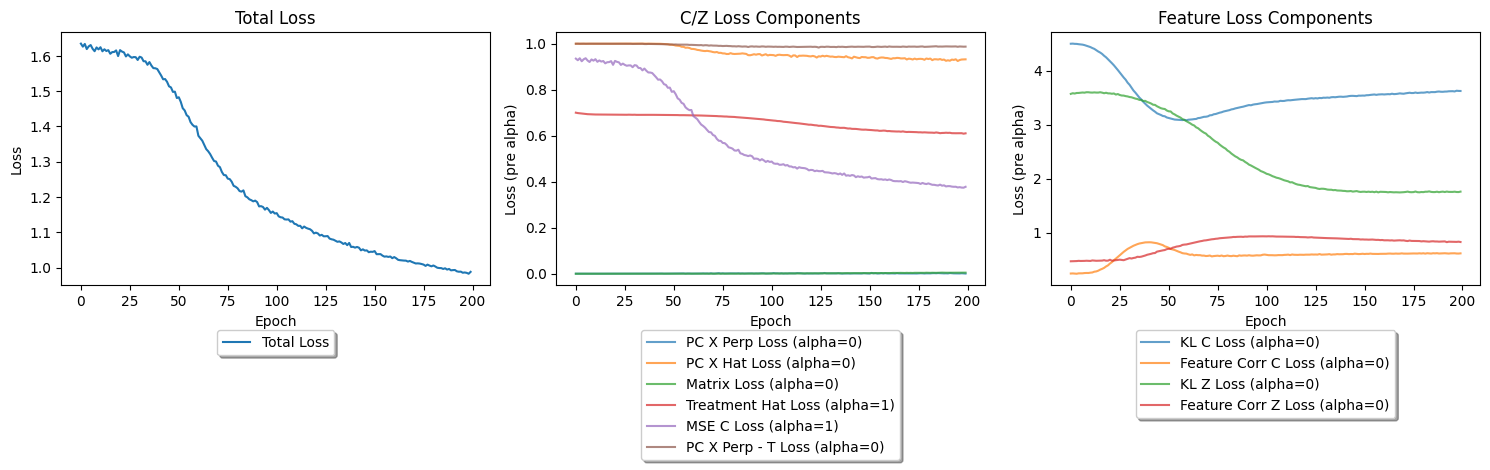

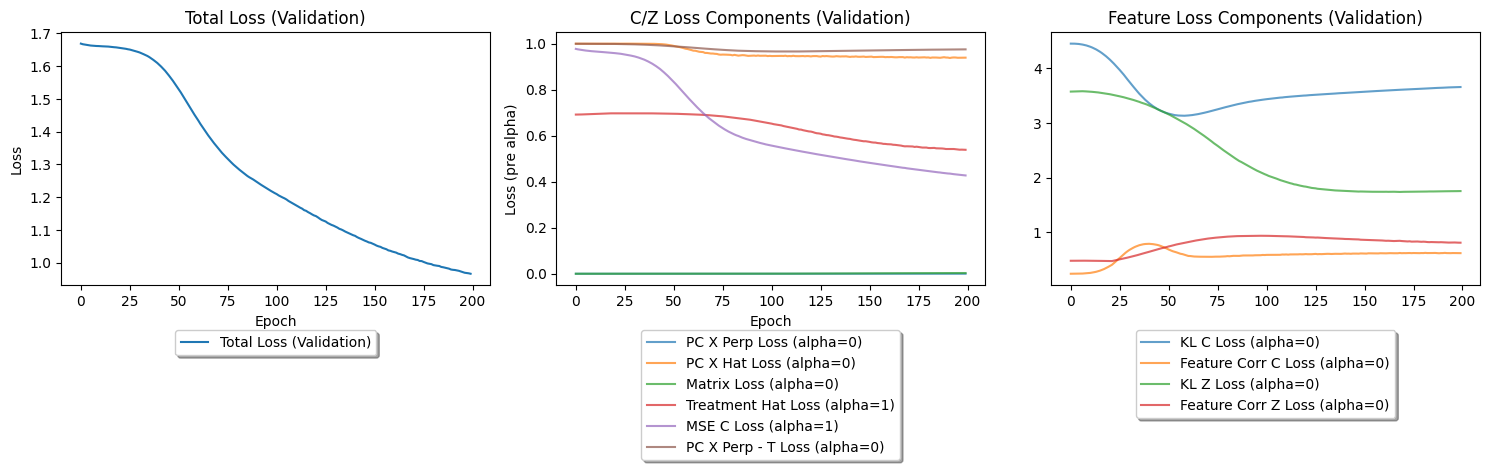

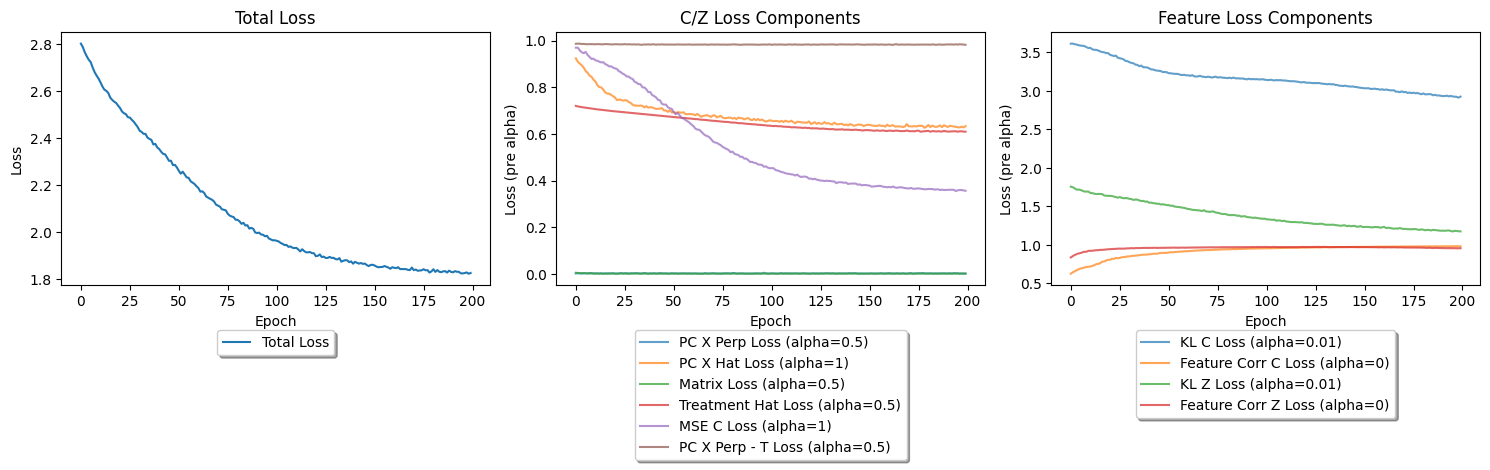

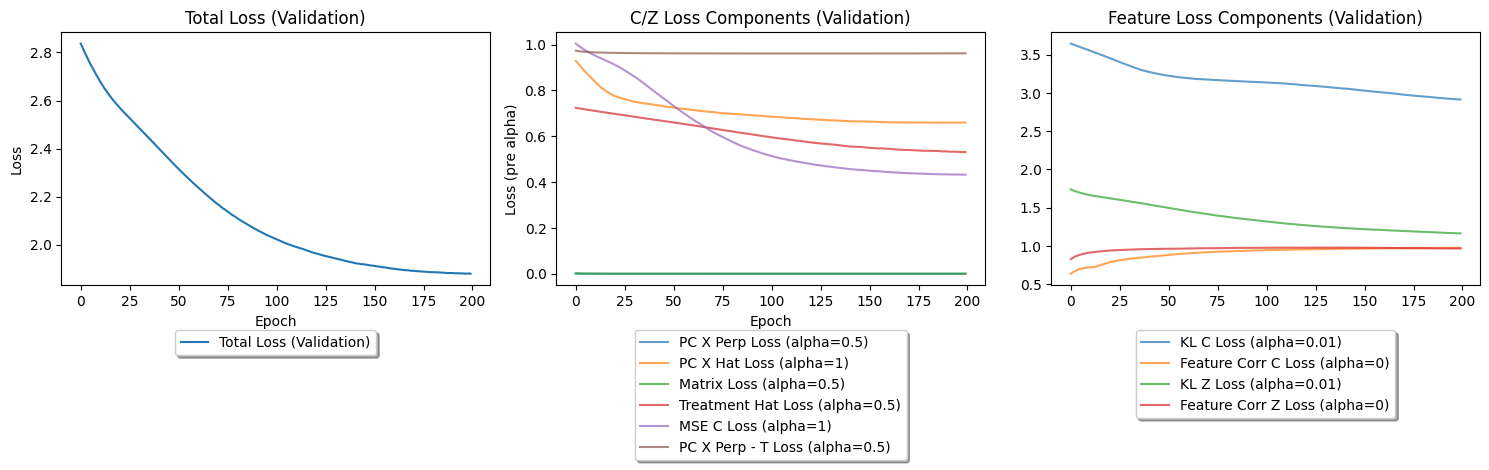

In [ ]:
# Sample run
znets, znet_data, _ = train_znet(datasets['linear_disjoint_no_U_to_X'][1], 
                                          model_params, 
                                          train_params, 
                                          dim_options,
                                          )

#### Downstream effect estimation

In [9]:
# Set parameters
deep_iv_params = {
            'batch_size': 100,
            'batch_size2': 100,
            'dropout': 0.2,
            'dropout2': 0.2,
            'hidden_size': 32,
            'hidden_size2': 32,
            'lr': 0.0005,
            'lr2': 0.0005,
            'epochs1': 100, # We may want to lower the epochs to speed things up
            'epochs2': 200, # We may want to lower the epochs to speed things up
            'early_stopping': False, # I am not sure which way we want this
            'patience': 10,
        }
df_iv_params = {
            'batch_size': 128,
            'dropout': 0.2,
            'hidden_size_phi': 20,
            'hidden_size_psi': 40,
            'hidden_size_xi': 20,
            'lambda1': 0.01,
            'lambda2': 0.02,
            'lr1': 0.001,
            'lr2': 0.001,
            'epochs': 200, # We may want to lower the epochs to speed things up
            'early_stopping': True, # I am not sure which way we want this
            'patience': 10
        }
eval_params = {
    'methods' : ['tsls', 'ols', 'diff_in_means', 'exogeneity', 'independence', 'relevance', 'deep_iv', 'df_iv'],
    'deep_iv_model_params' : deep_iv_params,
    'df_iv_model_params' : df_iv_params,
    'verbose': True
}


In [10]:
eval_results = evaluate_generatediv_dataset(znet_data, eval_params)

Train 2SLS CATE: 0.2502889340561429
Val 2SLS ATE: 0.5532875743011014
Test 2SLS ATE: 0.5324530628777189
OLS CATE: 0.44457904526754033
Val OLS ATE: 0.3795404559458213
Test OLS ATE: 0.44499201853371617

Evaluating train split:
ATE (Diff in Means): 0.44051517028562626

Evaluating val split:
ATE (Diff in Means): 0.38059555227587805

Evaluating test split:
ATE (Diff in Means): 0.38650472235628286

Evaluating train split:
Average |correlation| of residuals of Y with each column of X_perp:
0.030683788363471253
Average |covariance| of residuals of Y with each column of X_perp:
0.0031343999197812437

Evaluating val split:
Average |correlation| of residuals of Y with each column of X_perp:
0.05333055632536912
Average |covariance| of residuals of Y with each column of X_perp:
0.005501090866937622

Evaluating test split:
Average |correlation| of residuals of Y with each column of X_perp:
0.01506994530869135
Average |covariance| of residuals of Y with each column of X_perp:
0.00091399995852992

Eval

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/wynton/protected/home/alaa/franny_dean/.conda/envs/znet2/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=71` in the `DataLoader` to improve performance.
/wynton/protected/home/alaa/franny_dean/.conda/envs/znet2/lib/python3.10/site-packages/pytorch_lightning/core/module.py:512: You called `self.log('val_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/wynton/protected/home/alaa/franny_dean/.conda/envs/znet2/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` 

In [11]:
eval_results

{'train_TSLS_ATE': 0.2502889340561429,
 'val_TSLS_ATE': 0.5532875743011014,
 'test_TSLS_ATE': 0.5324530628777189,
 'train_OLS_ATE': 0.44457904526754033,
 'val_OLS_ATE': 0.3795404559458213,
 'test_OLS_ATE': 0.44499201853371617,
 'train_diff_in_means_ATE': 0.44051517028562626,
 'val_diff_in_means_ATE': 0.38059555227587805,
 'test_diff_in_means_ATE': 0.38650472235628286,
 'train_exogeneity_cov': 0.0031343999197812437,
 'train_exogeneity_corr': 0.030683788363471253,
 'val_exogeneity_cov': 0.005501090866937622,
 'val_exogeneity_corr': 0.05333055632536912,
 'test_exogeneity_cov': 0.00091399995852992,
 'test_exogeneity_corr': 0.01506994530869135,
 'train_independence_cov': 0.0004569813127845772,
 'train_independence_corr': 0.06355559019339703,
 'val_independence_cov': 0.00030473577078619837,
 'val_independence_corr': 0.043208878817219264,
 'test_independence_cov': 0.00023161414069797836,
 'test_independence_corr': 0.037391176123871425,
 'train_relevance_cov': 0.03413020155065826,
 'train_rele